# Chapter 4: Voronoi Diagrams

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Chapter 4, printed pages `107-135`, PDF pages `122-150`.

**Chapter goal.** Turn the Voronoi diagram from a proximity definition into a collection of inspectable computational objects: nearest-site loci, half-plane cell intersections, Voronoi-Delaunay duality, Euler-style complexity counts, incremental insertion, paraboloid lifting, and point-line/envelope duality.

The source pages were used for coverage and terminology only. The prose, point sets, diagrams, code, and checks below are original teaching material. Every visual has a concrete inspection target and a small invariant check so that the notebook can stand on its own without reproducing textbook figures or page layouts.


## Computational Translation Guide

| Chapter language | Computational representation | What we will inspect |
| --- | --- | --- |
| site set `S` | a fixed `n x 2` NumPy array | Euclidean distances from query points to sites |
| Voronoi region `Vor(p)` | inequalities `||x-p|| <= ||x-q||` for every other site `q` | one cell as an intersection of half-planes |
| bounded versus unbounded cell | finite versus infinite region in `scipy.spatial.Voronoi` | hull sites have unbounded cells; interior sites have bounded cells |
| Voronoi edge or vertex | ridge adjacency and equidistant circle center | empty-circle witnesses |
| straight-line dual | `scipy.spatial.Delaunay` edges | Delaunay edges match Voronoi region adjacencies |
| complexity bound | counts of finite vertices, ridges, and faces | `(V+1)-E+F=2`, `V <= 2n-5`, `E <= 3n-6` |
| lifting to `z=x^2+y^2` | 3D convex hull of lifted sites | lower hull facets project to Delaunay triangles |
| geometric duality | line `y=mx+b` maps to point `(m,-b)`; point `(a,b)` maps to line `y=ax-b` | incidence, order reversal, and envelope/hull correspondence |


## Visual Storyboard

1. **Nearest-site raster with exact edges.** Color query points by nearest site and overlay the exact Voronoi graph.
2. **Half-plane cell construction.** Build one bounded Voronoi cell as an intersection of linear inequalities.
3. **Voronoi-Delaunay dual overlay.** Compare region adjacency with Delaunay edges and empty-circle witnesses.
4. **Complexity and incremental insertion.** Record finite counts and show how adding one site changes local certificates.
5. **Paraboloid lifting and point-line duality.** Use 3D lower hulls and line/point dual diagrams to connect Voronoi geometry to convex hulls and envelopes.


## Source Coverage And Library Routing

**Library Routing.** `scipy.spatial.Voronoi`, `Delaunay`, `ConvexHull`, and `HalfspaceIntersection` match the chapter because the central objects are nearest-site regions, dual triangulations, lower hulls, and half-plane intersections. Matplotlib is used for static inspection diagrams; Plotly is used only for the 3D paraboloid-lifting artifact where rotation clarifies which hull facets are lower. CSV and JSON checks record adjacency, Euler-style counts, and incidence conditions so the visuals are not decorative.

The source span was read for concept coverage: Voronoi regions, bounded and unbounded cells, planar complexity, Delaunay duality, incremental insertion, paraboloid lifting, and point-line duality. The examples, coordinates, prose, and generated artifacts are original to this notebook.


In [1]:
from pathlib import Path
import itertools
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, Polygon
from matplotlib.path import Path as MplPath
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.spatial import ConvexHull, Delaunay, HalfspaceIntersection, KDTree, Voronoi, voronoi_plot_2d

COURSE_FOLDER = "Discrete-and-Computational-Geometry"

def locate_book_root():
    start = Path.cwd().resolve()
    candidates = [start, start / COURSE_FOLDER, *start.parents]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate the Discrete and Computational Geometry course root")

BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-04-voronoi-diagrams"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#343434",
    "axes.labelcolor": "#242424",
    "xtick.color": "#242424",
    "ytick.color": "#242424",
    "font.size": 10,
})

sites = np.array([
    [0.08, 0.18],
    [0.17, 0.76],
    [0.32, 0.42],
    [0.44, 0.86],
    [0.52, 0.21],
    [0.64, 0.62],
    [0.76, 0.34],
    [0.82, 0.82],
    [0.91, 0.12],
    [0.25, 0.12],
], dtype=float)
site_labels = [f"s{i}" for i in range(len(sites))]
plot_bounds = (-0.06, 1.07, -0.06, 1.04)

palette = [
    "#4477aa", "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
    "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3", "#dd6b20",
]
cmap = ListedColormap(palette)

library_routing = [
    {"concept": "nearest-site regions", "representation": "colored query grid", "library": "NumPy + SciPy KDTree + Matplotlib", "why": "directly compares Euclidean distances and gives a durable 2D artifact"},
    {"concept": "cell as half-plane intersection", "representation": "linear inequalities clipped to a teaching window", "library": "SciPy HalfspaceIntersection + Matplotlib", "why": "keeps Theorem 4.1 visible as inequalities rather than a black-box diagram"},
    {"concept": "Voronoi-Delaunay duality", "representation": "ridge adjacency overlaid with straight Delaunay edges", "library": "scipy.spatial.Voronoi and Delaunay", "why": "the same site set exposes both structures and a set equality check"},
    {"concept": "combinatorial complexity", "representation": "CSV ledger and bound plot", "library": "pandas + SciPy + Matplotlib", "why": "turns Euler-style counting into auditable rows"},
    {"concept": "incremental insertion", "representation": "marked Delaunay cavity and new star", "library": "SciPy Delaunay + Matplotlib", "why": "the local update is easier to inspect through the dual triangulation"},
    {"concept": "paraboloid lifting", "representation": "interactive lower hull on z=x^2+y^2", "library": "SciPy ConvexHull + Plotly", "why": "3D rotation is the natural view for lower hull facets"},
    {"concept": "point-line duality and envelopes", "representation": "line arrangement beside dual hull", "library": "NumPy + SciPy ConvexHull + Matplotlib", "why": "incidence and order reversal are numerical equalities"},
]
routing_path = save_csv(library_routing, TABLES / "library-routing.csv")
pd.DataFrame(library_routing)


,concept,representation,library,why
0,nearest-site regions,colored query grid,NumPy + SciPy KDTree + Matplotlib,directly compares Euclidean distances and give...
1,cell as half-plane intersection,linear inequalities clipped to a teaching window,SciPy HalfspaceIntersection + Matplotlib,keeps Theorem 4.1 visible as inequalities rath...
2,Voronoi-Delaunay duality,ridge adjacency overlaid with straight Delauna...,scipy.spatial.Voronoi and Delaunay,the same site set exposes both structures and ...
3,combinatorial complexity,CSV ledger and bound plot,pandas + SciPy + Matplotlib,turns Euler-style counting into auditable rows
4,incremental insertion,marked Delaunay cavity and new star,SciPy Delaunay + Matplotlib,the local update is easier to inspect through ...
5,paraboloid lifting,interactive lower hull on z=x^2+y^2,SciPy ConvexHull + Plotly,3D rotation is the natural view for lower hull...
6,point-line duality and envelopes,line arrangement beside dual hull,NumPy + SciPy ConvexHull + Matplotlib,incidence and order reversal are numerical equ...


## 1. Nearest-Site Loci

A Voronoi region is a nearest-site locus. The most literal computational translation is to sample many query points, compute their distances to all sites, and color each query by the index of its nearest site. The black curves are the exact Voronoi edges from SciPy; the colored grid is only a raster witness for the same nearest-site rule.

Inspection target: away from a black edge, every small patch has one nearest site; on an edge, the winning site changes.


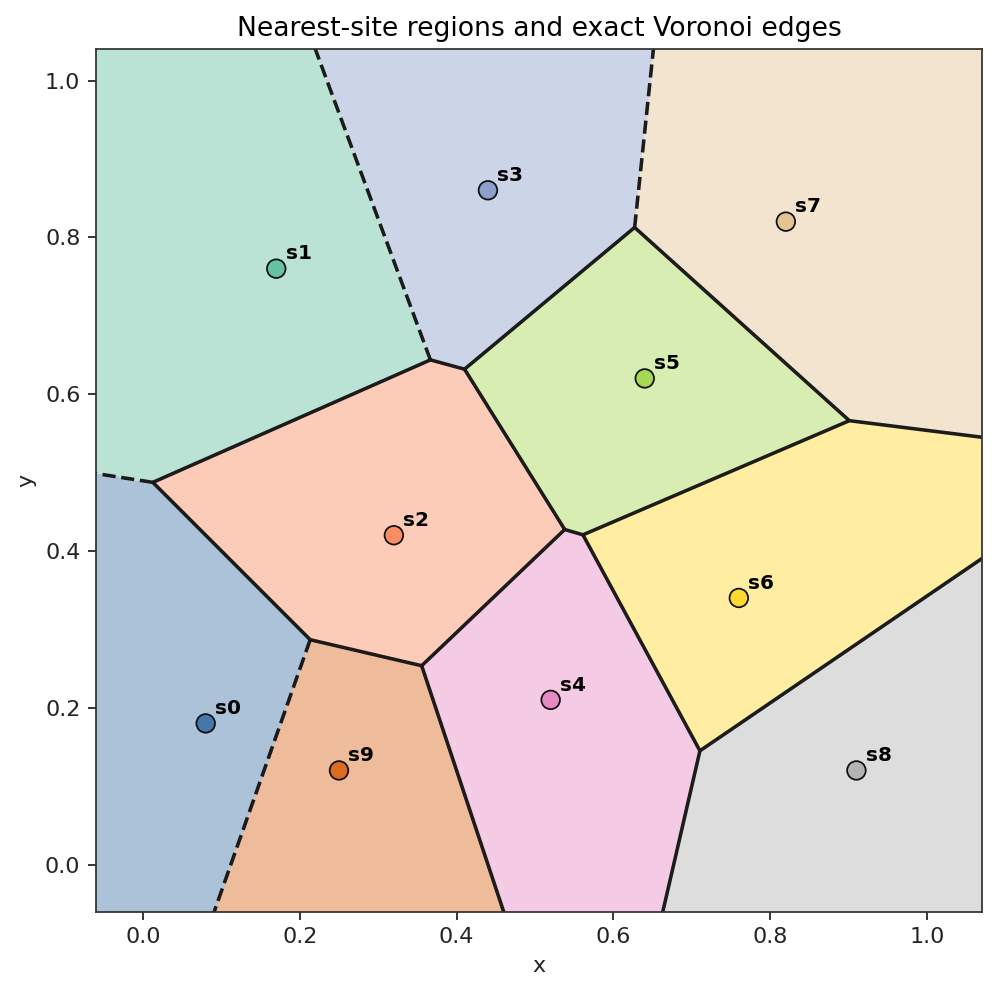

{'probe_points': [[0.1, 0.2],
  [0.5, 0.5],
  [0.88, 0.2],
  [0.35, 0.82],
  [0.68, 0.7]],
 'manual_nearest': [0, 5, 8, 3, 5],
 'kdtree_nearest': [0, 5, 8, 3, 5],
 'matches_kdtree': True,
 'grid_min_second_minus_first_distance_squared': 2.233252143074571e-07,
 'bounded_sites': [2, 4, 5, 6],
 'unbounded_sites': [0, 1, 3, 7, 8, 9],
 'hull_sites': [0, 1, 3, 7, 8, 9],
 'bounded_iff_not_hull': True}

In [2]:
vor = Voronoi(sites)
tri = Delaunay(sites)
hull = ConvexHull(sites)
hull_sites = set(map(int, hull.vertices))

xs = np.linspace(plot_bounds[0], plot_bounds[1], 420)
ys = np.linspace(plot_bounds[2], plot_bounds[3], 390)
X, Y = np.meshgrid(xs, ys)
queries = np.column_stack([X.ravel(), Y.ravel()])
dist2 = ((queries[:, None, :] - sites[None, :, :]) ** 2).sum(axis=2)
nearest = np.argmin(dist2, axis=1).reshape(X.shape)
margin = np.partition(dist2, 1, axis=1)[:, 1] - np.partition(dist2, 0, axis=1)[:, 0]

fig, ax = plt.subplots(figsize=(8.4, 7.0))
ax.imshow(nearest, extent=plot_bounds, origin="lower", cmap=cmap, alpha=0.45, interpolation="nearest", aspect="auto")
voronoi_plot_2d(vor, ax=ax, show_vertices=False, show_points=False, line_colors="#111111", line_width=1.6, line_alpha=0.95)
ax.scatter(sites[:, 0], sites[:, 1], s=70, c=palette, edgecolors="#111111", linewidths=0.8, zorder=4)
for i, (x, y) in enumerate(sites):
    ax.text(x + 0.012, y + 0.012, site_labels[i], fontsize=9, weight="bold")
ax.set_xlim(plot_bounds[0], plot_bounds[1])
ax.set_ylim(plot_bounds[2], plot_bounds[3])
ax.set_aspect("equal")
ax.set_title("Nearest-site regions and exact Voronoi edges")
ax.set_xlabel("x")
ax.set_ylabel("y")
nearest_grid_path = save_matplotlib(fig, FIGURES / "nearest-site-grid.png")
plt.close(fig)

kd_tree = KDTree(sites)
probe = np.array([
    [0.10, 0.20],
    [0.50, 0.50],
    [0.88, 0.20],
    [0.35, 0.82],
    [0.68, 0.70],
])
manual_nearest = np.argmin(((probe[:, None, :] - sites[None, :, :]) ** 2).sum(axis=2), axis=1)
kdtree_nearest = kd_tree.query(probe)[1]
region_bounded = []
for region_index in vor.point_region:
    region = vor.regions[region_index]
    bounded = bool(region) and (-1 not in region)
    region_bounded.append(bounded)

nearest_check = {
    "probe_points": probe.round(4).tolist(),
    "manual_nearest": manual_nearest.astype(int).tolist(),
    "kdtree_nearest": kdtree_nearest.astype(int).tolist(),
    "matches_kdtree": bool(np.array_equal(manual_nearest, kdtree_nearest)),
    "grid_min_second_minus_first_distance_squared": float(margin.min()),
    "bounded_sites": [i for i, bounded in enumerate(region_bounded) if bounded],
    "unbounded_sites": [i for i, bounded in enumerate(region_bounded) if not bounded],
    "hull_sites": sorted(hull_sites),
    "bounded_iff_not_hull": bool(all(region_bounded[i] == (i not in hull_sites) for i in range(len(sites)))),
}
nearest_check_path = save_json(nearest_check, CHECKS / "nearest-site-grid-checks.json")
display_artifact(nearest_grid_path, width=760)
nearest_check


The bounded/unbounded distinction is visible in two ways. A site on the convex hull owns directions that go to infinity, so its Voronoi region is unbounded. An interior site is fenced in by competitors in every direction, so its region is bounded. The JSON check records this as `bounded_iff_not_hull` for the current point set.


## 2. One Cell as a Half-Plane Intersection

For two sites `p` and `q`, the inequality `||x-p|| <= ||x-q||` simplifies to a linear half-plane:

`2(q-p) dot x <= ||q||^2 - ||p||^2`.

So `Vor(p)` is not mysterious: it is the intersection of one half-plane for every competing site. The next cell chooses an interior site, draws all relevant perpendicular bisectors, and computes the clipped polygon from those inequalities.


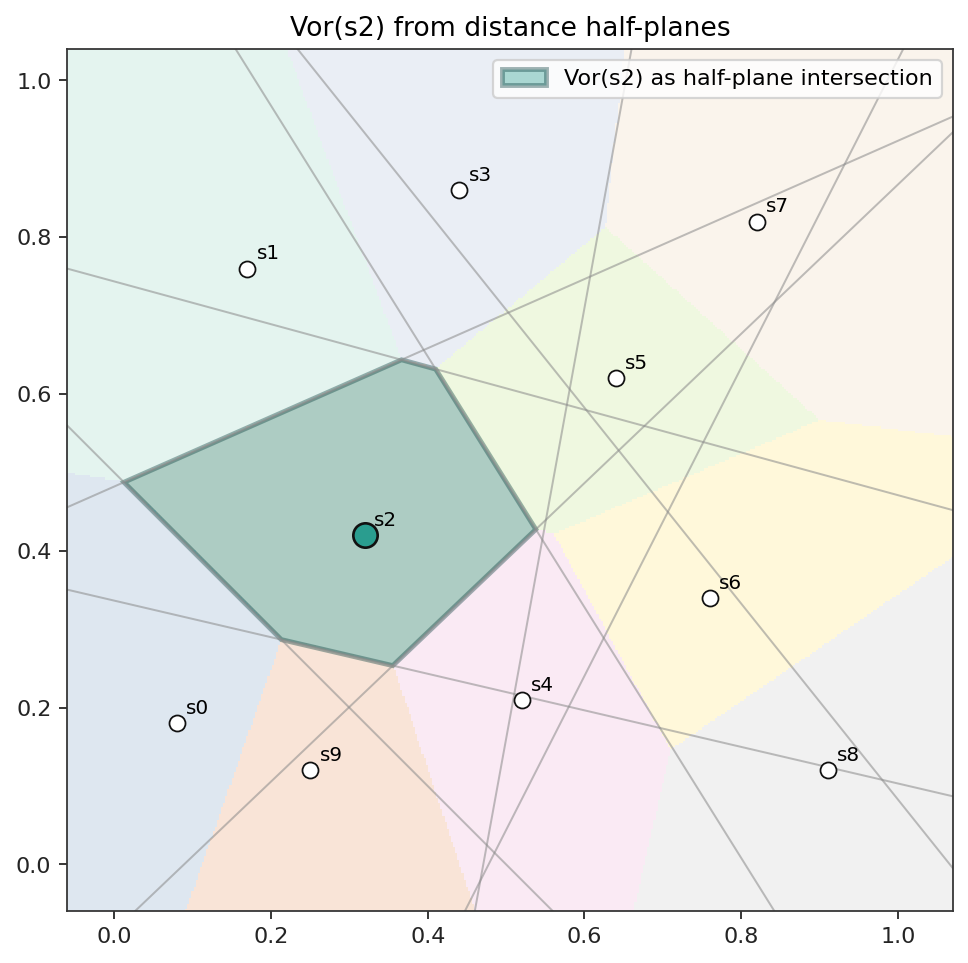

{'site_index': 2,
 'competing_halfplanes': 9,
 'cell_vertex_count': 6,
 'cell_area': 0.1174426288192294,
 'max_halfspace_violation_at_vertices': 5.551115123125783e-17,
 'site_is_inside_clipped_cell': True,
 'bounded_iff_not_hull': True}

In [3]:
def halfspaces_for_site(points, site_index, bounds):
    p = points[site_index]
    halfspaces = []
    labels = []
    for j, q in enumerate(points):
        if j == site_index:
            continue
        normal = 2.0 * (q - p)
        offset = float(np.dot(p, p) - np.dot(q, q))
        halfspaces.append([normal[0], normal[1], offset])
        labels.append(f"H(s{site_index},s{j})")
    xmin, xmax, ymin, ymax = bounds
    halfspaces.extend([
        [-1.0, 0.0, xmin],
        [1.0, 0.0, -xmax],
        [0.0, -1.0, ymin],
        [0.0, 1.0, -ymax],
    ])
    labels.extend(["x lower clip", "x upper clip", "y lower clip", "y upper clip"])
    return np.array(halfspaces, dtype=float), labels

def order_polygon(vertices):
    center = vertices.mean(axis=0)
    angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
    return vertices[np.argsort(angles)]

def polygon_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def draw_bisector(ax, p, q, bounds, **kwargs):
    mid = 0.5 * (p + q)
    direction = np.array([-(q - p)[1], (q - p)[0]])
    direction = direction / np.linalg.norm(direction)
    t = np.linspace(-2.0, 2.0, 2)
    line = mid + t[:, None] * direction[None, :]
    ax.plot(line[:, 0], line[:, 1], **kwargs)

interior_sites = [i for i in range(len(sites)) if i not in hull_sites]
cell_index = interior_sites[0]
halfspaces, halfspace_labels = halfspaces_for_site(sites, cell_index, plot_bounds)
hsi = HalfspaceIntersection(halfspaces, sites[cell_index])
cell_poly = order_polygon(hsi.intersections)
cell_path = MplPath(cell_poly)

fig, ax = plt.subplots(figsize=(7.4, 7.0))
ax.imshow(nearest, extent=plot_bounds, origin="lower", cmap=cmap, alpha=0.18, interpolation="nearest", aspect="auto")
for j, q in enumerate(sites):
    if j != cell_index:
        draw_bisector(ax, sites[cell_index], q, plot_bounds, color="#8a8a8a", lw=0.9, alpha=0.55)
ax.add_patch(Polygon(cell_poly, closed=True, facecolor="#2a9d8f", edgecolor="#073b3a", alpha=0.38, lw=2.2, label=f"Vor(s{cell_index}) as half-plane intersection"))
ax.scatter(sites[:, 0], sites[:, 1], s=52, c="#ffffff", edgecolors="#111111", linewidths=0.8, zorder=3)
ax.scatter([sites[cell_index, 0]], [sites[cell_index, 1]], s=120, c="#2a9d8f", edgecolors="#111111", linewidths=1.2, zorder=4)
for i, (x, y) in enumerate(sites):
    ax.text(x + 0.012, y + 0.012, site_labels[i], fontsize=9)
ax.set_xlim(plot_bounds[0], plot_bounds[1])
ax.set_ylim(plot_bounds[2], plot_bounds[3])
ax.set_aspect("equal")
ax.set_title(f"Vor(s{cell_index}) from distance half-planes")
ax.legend(loc="upper right")
halfplane_path = save_matplotlib(fig, FIGURES / "halfplane-cell-construction.png")
plt.close(fig)

violations = halfspaces[:, :2] @ cell_poly.T + halfspaces[:, 2:3]
halfplane_check = {
    "site_index": int(cell_index),
    "competing_halfplanes": int(len(sites) - 1),
    "cell_vertex_count": int(len(cell_poly)),
    "cell_area": float(polygon_area(cell_poly)),
    "max_halfspace_violation_at_vertices": float(violations.max()),
    "site_is_inside_clipped_cell": bool(cell_path.contains_point(sites[cell_index])),
    "bounded_iff_not_hull": nearest_check["bounded_iff_not_hull"],
}
halfplane_check_path = save_json(halfplane_check, CHECKS / "halfplane-cell-checks.json")
display_artifact(halfplane_path, width=720)
halfplane_check


## 3. Delaunay as the Straight-Line Dual

The Voronoi diagram records which sites have neighboring regions. If we connect those neighboring sites by straight segments, the result is the Delaunay triangulation for a general-position set. The empty-circle criterion explains why: a Voronoi vertex is equidistant from the triangle sites, and no other site lies inside the circle centered there.

Inspection target: every red Delaunay edge crosses or touches the black Voronoi edge separating the same two site regions. The highlighted circle is empty except for its three triangle vertices.


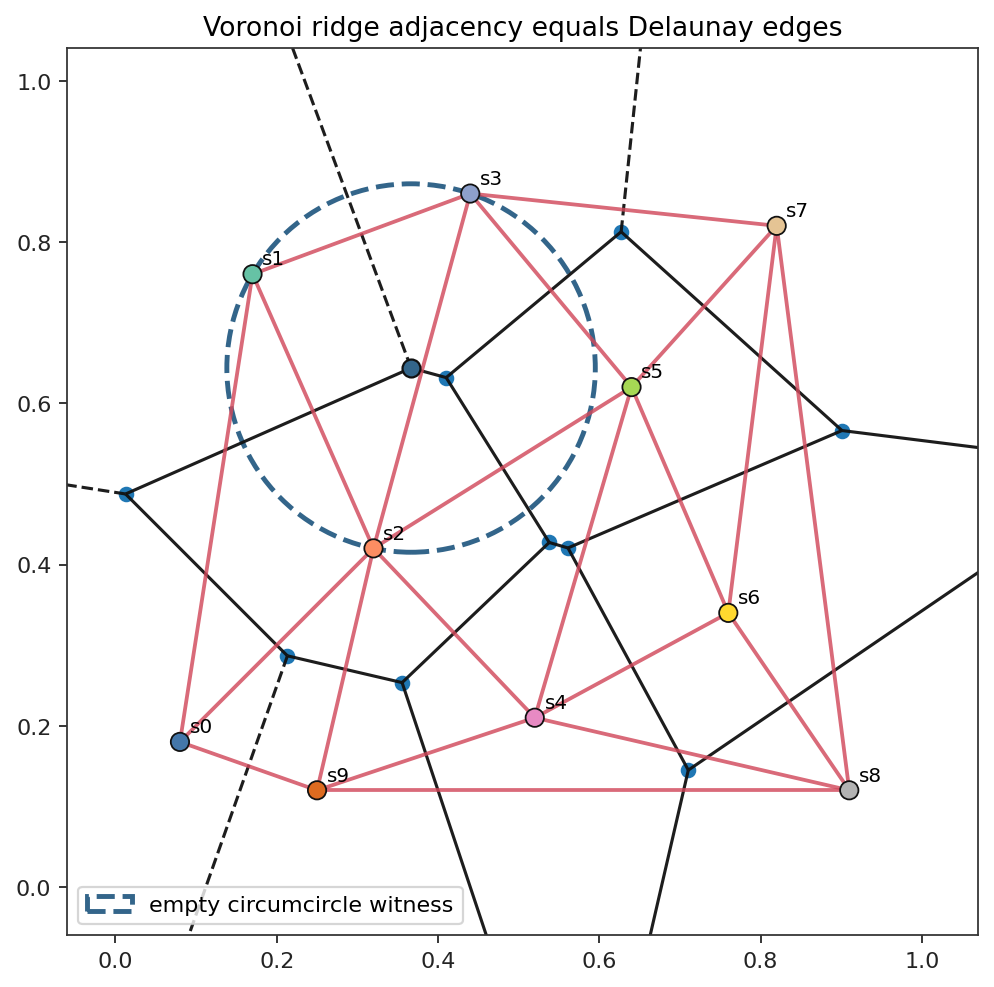

{'voronoi_ridge_edge_count': 21,
 'delaunay_edge_count': 21,
 'edge_sets_agree': True,
 'selected_triangle': [1, 2, 3],
 'circumcenter': [0.36661049, 0.64365169],
 'radius': 0.2284570284922243,
 'max_radius_error_on_triangle_vertices': 2.498001805406602e-16,
 'empty_circle_margin_to_other_sites': 0.04595366390096026,
 'empty_circle_is_empty': True}

In [4]:
def delaunay_edges(triangulation):
    edges = set()
    for simplex in triangulation.simplices:
        for a, b in itertools.combinations(simplex, 2):
            edges.add(tuple(sorted((int(a), int(b)))))
    return edges

def voronoi_ridge_edges(voronoi):
    return {tuple(sorted(map(int, pair))) for pair in voronoi.ridge_points}

def circumcenter_radius(triangle_points):
    a, b, c = triangle_points
    A = 2 * np.array([[b[0] - a[0], b[1] - a[1]], [c[0] - a[0], c[1] - a[1]]], dtype=float)
    rhs = np.array([
        np.dot(b, b) - np.dot(a, a),
        np.dot(c, c) - np.dot(a, a),
    ], dtype=float)
    center = np.linalg.solve(A, rhs)
    radius = float(np.linalg.norm(center - a))
    return center, radius

tri_edges = delaunay_edges(tri)
vor_edges = voronoi_ridge_edges(vor)
selected_simplex = tri.simplices[3]
center, radius = circumcenter_radius(sites[selected_simplex])
distances_to_center = np.linalg.norm(sites - center, axis=1)
other_indices = [i for i in range(len(sites)) if i not in selected_simplex]
empty_margin = float(distances_to_center[other_indices].min() - radius)

fig, ax = plt.subplots(figsize=(8.0, 7.2))
voronoi_plot_2d(vor, ax=ax, show_vertices=True, show_points=False, line_colors="#111111", line_width=1.4, line_alpha=0.95, point_size=8)
for a, b in sorted(tri_edges):
    ax.plot([sites[a, 0], sites[b, 0]], [sites[a, 1], sites[b, 1]], color="#d1495b", lw=1.7, alpha=0.82, zorder=2)
ax.add_patch(Circle(center, radius, fill=False, color="#33658a", lw=2.2, linestyle="--", label="empty circumcircle witness"))
ax.scatter(sites[:, 0], sites[:, 1], s=68, c=palette, edgecolors="#111111", linewidths=0.8, zorder=4)
ax.scatter([center[0]], [center[1]], s=65, c="#33658a", edgecolors="#111111", zorder=5)
for i, (x, y) in enumerate(sites):
    ax.text(x + 0.012, y + 0.012, site_labels[i], fontsize=9)
ax.set_xlim(plot_bounds[0], plot_bounds[1])
ax.set_ylim(plot_bounds[2], plot_bounds[3])
ax.set_aspect("equal")
ax.set_title("Voronoi ridge adjacency equals Delaunay edges")
ax.legend(loc="lower left")
dual_overlay_path = save_matplotlib(fig, FIGURES / "voronoi-delaunay-dual-overlay.png")
plt.close(fig)

duality_check = {
    "voronoi_ridge_edge_count": int(len(vor_edges)),
    "delaunay_edge_count": int(len(tri_edges)),
    "edge_sets_agree": bool(vor_edges == tri_edges),
    "selected_triangle": sorted(map(int, selected_simplex)),
    "circumcenter": center.round(8).tolist(),
    "radius": radius,
    "max_radius_error_on_triangle_vertices": float(np.max(np.abs(distances_to_center[selected_simplex] - radius))),
    "empty_circle_margin_to_other_sites": empty_margin,
    "empty_circle_is_empty": bool(empty_margin > 1e-10),
}
duality_check_path = save_json(duality_check, CHECKS / "voronoi-delaunay-dual-checks.json")
display_artifact(dual_overlay_path, width=740)
duality_check


## 4. Combinatorics and Linear Complexity

A naive count begins with all site-site bisectors and suggests quadratic complexity. The Voronoi diagram is much smaller. After bending all unbounded rays to a single auxiliary vertex, Euler's formula gives `(V+1)-E+F=2`, and degree counting gives the bounds `V <= 2n-5` and `E <= 3n-6`.

The ledger below samples several general-position point sets. It records actual finite Voronoi vertices `V`, Voronoi ridges `E`, faces `F=n`, hull size `h`, and the sharper generic formulas `V=2n-2-h`, `E=3n-3-h`.


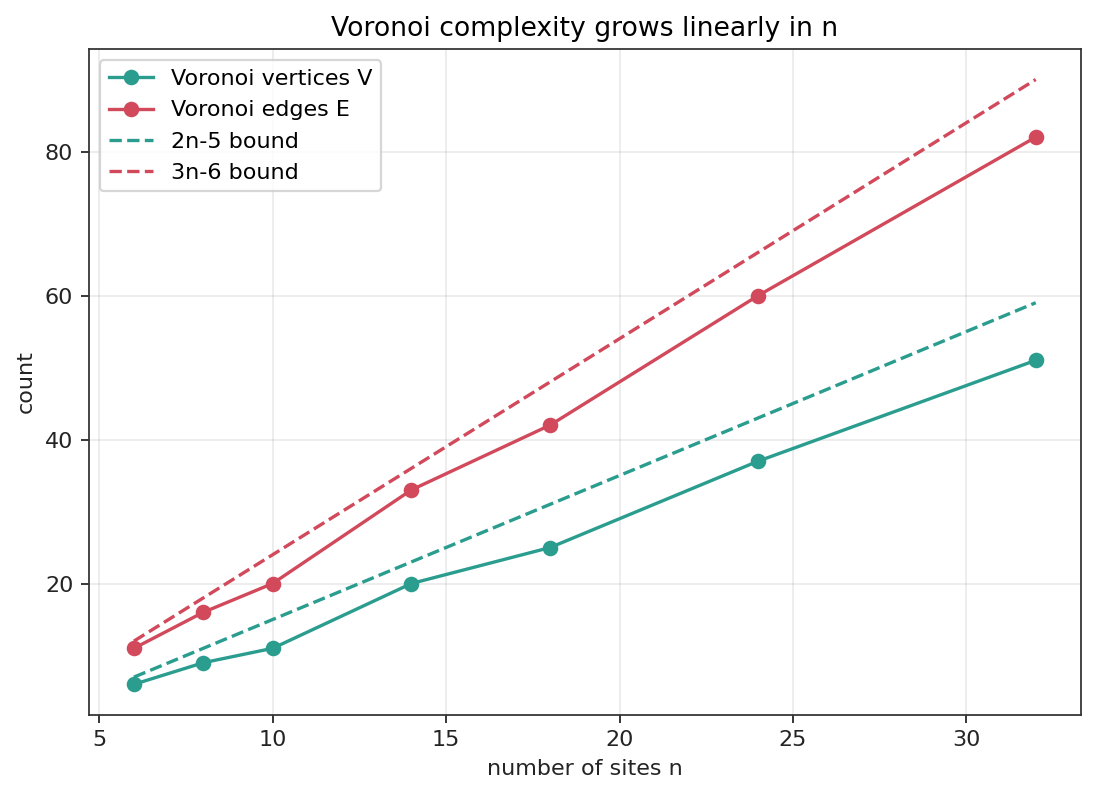

,n,hull_vertices_h,V_finite_vertices,E_voronoi_edges_or_ridges,F_regions,Euler_(V+1)-E+F,V_bound_2n_minus_5,E_bound_3n_minus_6,V_expected_2n_minus_2_minus_h,E_expected_3n_minus_3_minus_h,Delaunay_triangles
0,6,4,6,11,6,2,7,12,6,11,6
1,8,5,9,16,8,2,11,18,9,16,9
2,10,7,11,20,10,2,15,24,11,20,11
3,14,6,20,33,14,2,23,36,20,33,20
4,18,9,25,42,18,2,31,48,25,42,25
5,24,9,37,60,24,2,43,66,37,60,37
6,32,11,51,82,32,2,59,90,51,82,51


In [5]:
def sampled_sites(n, seed):
    rng = np.random.default_rng(seed)
    pts = rng.uniform(0.05, 0.95, size=(n, 2))
    pts[:, 0] += np.linspace(-0.0007, 0.0007, n)
    pts[:, 1] += 0.0005 * np.sin(np.arange(n))
    return pts

ledger_rows = []
for n in [6, 8, 10, 14, 18, 24, 32]:
    pts = sampled_sites(n, seed=400 + n)
    local_vor = Voronoi(pts)
    local_tri = Delaunay(pts)
    local_hull = ConvexHull(pts)
    V = len(local_vor.vertices)
    E = len(local_vor.ridge_points)
    F = n
    h = len(local_hull.vertices)
    ledger_rows.append({
        "n": n,
        "hull_vertices_h": h,
        "V_finite_vertices": V,
        "E_voronoi_edges_or_ridges": E,
        "F_regions": F,
        "Euler_(V+1)-E+F": (V + 1) - E + F,
        "V_bound_2n_minus_5": 2 * n - 5,
        "E_bound_3n_minus_6": 3 * n - 6,
        "V_expected_2n_minus_2_minus_h": 2 * n - 2 - h,
        "E_expected_3n_minus_3_minus_h": 3 * n - 3 - h,
        "Delaunay_triangles": len(local_tri.simplices),
    })
ledger = pd.DataFrame(ledger_rows)
complexity_csv_path = save_csv(ledger_rows, TABLES / "voronoi-complexity-ledger.csv")

fig, ax = plt.subplots(figsize=(8.0, 5.4))
ax.plot(ledger["n"], ledger["V_finite_vertices"], marker="o", color="#2a9d8f", label="Voronoi vertices V")
ax.plot(ledger["n"], ledger["E_voronoi_edges_or_ridges"], marker="o", color="#d1495b", label="Voronoi edges E")
ax.plot(ledger["n"], ledger["V_bound_2n_minus_5"], color="#2a9d8f", linestyle="--", label="2n-5 bound")
ax.plot(ledger["n"], ledger["E_bound_3n_minus_6"], color="#d1495b", linestyle="--", label="3n-6 bound")
ax.set_xlabel("number of sites n")
ax.set_ylabel("count")
ax.set_title("Voronoi complexity grows linearly in n")
ax.grid(True, alpha=0.25)
ax.legend()
complexity_plot_path = save_matplotlib(fig, FIGURES / "voronoi-complexity-bounds.png")
plt.close(fig)

complexity_check = {
    "row_count": int(len(ledger)),
    "all_euler_ledgers_equal_2": bool((ledger["Euler_(V+1)-E+F"] == 2).all()),
    "all_vertex_bounds_hold": bool((ledger["V_finite_vertices"] <= ledger["V_bound_2n_minus_5"]).all()),
    "all_edge_bounds_hold": bool((ledger["E_voronoi_edges_or_ridges"] <= ledger["E_bound_3n_minus_6"]).all()),
    "all_sharp_vertex_formulas_hold": bool((ledger["V_finite_vertices"] == ledger["V_expected_2n_minus_2_minus_h"]).all()),
    "all_sharp_edge_formulas_hold": bool((ledger["E_voronoi_edges_or_ridges"] == ledger["E_expected_3n_minus_3_minus_h"]).all()),
}
complexity_check_path = save_json(complexity_check, CHECKS / "voronoi-complexity-ledger.json")
display_artifact(complexity_plot_path, width=760)
ledger


## 5. Incremental Site Insertion

The source presents a local incremental Voronoi update and then revisits it through the Delaunay dual. The dual view is excellent for computation: insert a new site, mark exactly the old Delaunay triangles whose circumcircles contain the new site, remove the interior diagonals of that marked cavity, and connect the new site to the cavity boundary.

Inspection target: the middle panel shows the only triangles that can change; the right panel shows the star from the new site to the cavity boundary.


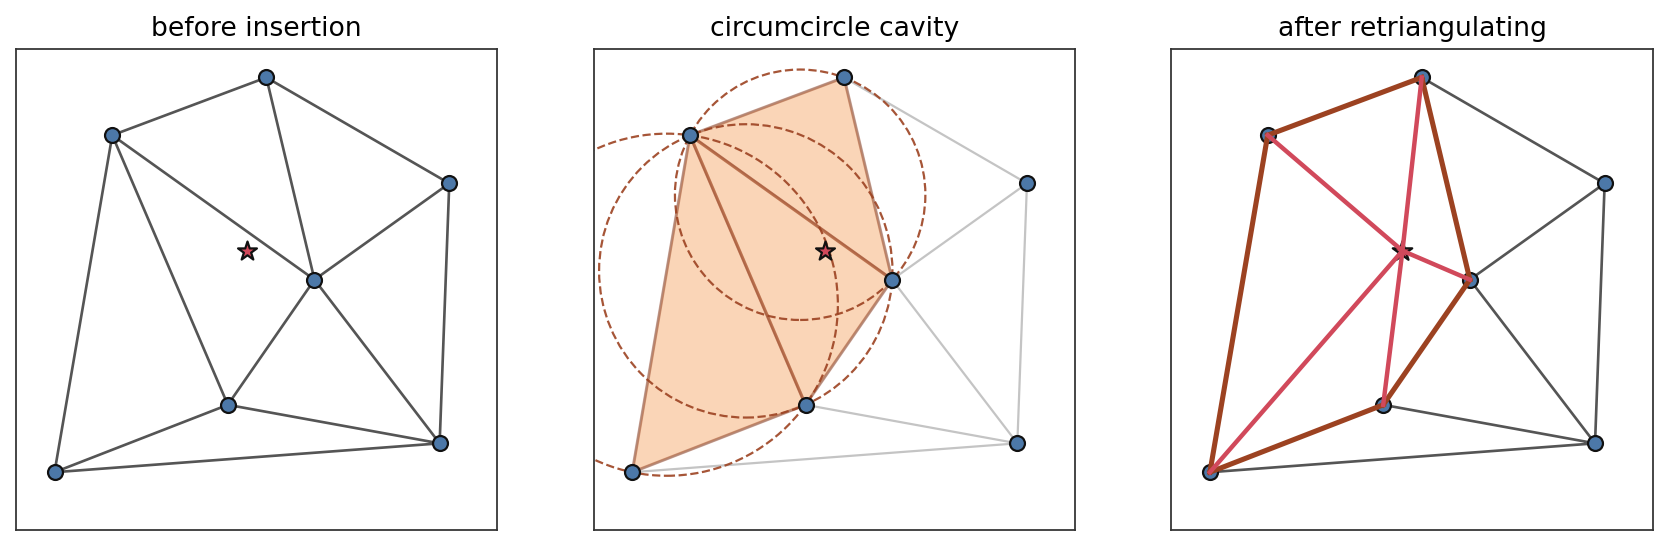

{'new_site_inside_old_hull': True,
 'marked_triangle_count': 3,
 'cavity_boundary_edges': [[0, 1], [0, 5], [1, 2], [2, 6], [5, 6]],
 'cavity_boundary_vertices': [0, 1, 2, 5, 6],
 'unmarked_old_triangles_survive': True,
 'new_edges_match_cavity_boundary_vertices': True}

In [6]:
def triangle_circumcircle_contains(triangle_points, point, tol=1e-12):
    center, radius = circumcenter_radius(triangle_points)
    return np.linalg.norm(point - center) < radius - tol, center, radius

incremental_before = np.array([
    [0.08, 0.12],
    [0.20, 0.82],
    [0.52, 0.94],
    [0.90, 0.72],
    [0.88, 0.18],
    [0.44, 0.26],
    [0.62, 0.52],
], dtype=float)
new_site = np.array([0.48, 0.58], dtype=float)
incremental_after = np.vstack([incremental_before, new_site])
new_index = len(incremental_after) - 1
old_tri = Delaunay(incremental_before)
new_tri = Delaunay(incremental_after)
old_hull_path = MplPath(incremental_before[ConvexHull(incremental_before).vertices])
new_site_inside_old_hull = bool(old_hull_path.contains_point(new_site))

marked = []
circumcircles = []
for simplex in old_tri.simplices:
    contains, cc, rr = triangle_circumcircle_contains(incremental_before[simplex], new_site)
    if contains:
        marked.append(tuple(sorted(map(int, simplex))))
        circumcircles.append((cc, rr))
marked_set = set(marked)

edge_multiplicity = {}
for simplex in marked:
    for edge in itertools.combinations(simplex, 2):
        edge = tuple(sorted(edge))
        edge_multiplicity[edge] = edge_multiplicity.get(edge, 0) + 1
cavity_boundary_edges = sorted(edge for edge, count in edge_multiplicity.items() if count == 1)
cavity_boundary_vertices = sorted({v for edge in cavity_boundary_edges for v in edge})
new_triangles = {tuple(sorted(map(int, simplex))) for simplex in new_tri.simplices}
unmarked_old = {tuple(sorted(map(int, simplex))) for simplex in old_tri.simplices} - marked_set
new_edges_to_old = {tuple(sorted((new_index, v))) for v in cavity_boundary_vertices}
actual_new_edges = {edge for edge in delaunay_edges(new_tri) if new_index in edge}

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), sharex=True, sharey=True)
for ax in axes:
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].triplot(incremental_before[:, 0], incremental_before[:, 1], old_tri.simplices, color="#555555", lw=1.2)
axes[0].scatter(incremental_before[:, 0], incremental_before[:, 1], s=45, color="#4c78a8", edgecolors="#111111")
axes[0].scatter([new_site[0]], [new_site[1]], s=80, marker="*", color="#d1495b", edgecolors="#111111")
axes[0].set_title("before insertion")

axes[1].triplot(incremental_before[:, 0], incremental_before[:, 1], old_tri.simplices, color="#c4c4c4", lw=1.0)
for simplex in marked_set:
    poly = incremental_before[list(simplex)]
    axes[1].add_patch(Polygon(poly, closed=True, facecolor="#f4a261", edgecolor="#9c4221", alpha=0.45, lw=1.4))
for cc, rr in circumcircles:
    axes[1].add_patch(Circle(cc, rr, fill=False, color="#9c4221", lw=1.0, linestyle="--", alpha=0.9))
axes[1].scatter(incremental_before[:, 0], incremental_before[:, 1], s=45, color="#4c78a8", edgecolors="#111111")
axes[1].scatter([new_site[0]], [new_site[1]], s=80, marker="*", color="#d1495b", edgecolors="#111111")
axes[1].set_title("circumcircle cavity")

axes[2].triplot(incremental_after[:, 0], incremental_after[:, 1], new_tri.simplices, color="#555555", lw=1.2)
for a, b in cavity_boundary_edges:
    axes[2].plot([incremental_before[a, 0], incremental_before[b, 0]], [incremental_before[a, 1], incremental_before[b, 1]], color="#9c4221", lw=2.3)
for v in cavity_boundary_vertices:
    axes[2].plot([new_site[0], incremental_before[v, 0]], [new_site[1], incremental_before[v, 1]], color="#d1495b", lw=2.0)
axes[2].scatter(incremental_after[:-1, 0], incremental_after[:-1, 1], s=45, color="#4c78a8", edgecolors="#111111")
axes[2].scatter([new_site[0]], [new_site[1]], s=85, marker="*", color="#d1495b", edgecolors="#111111")
axes[2].set_title("after retriangulating")

incremental_path = save_matplotlib(fig, FIGURES / "incremental-insertion-snapshots.png")
plt.close(fig)

incremental_check = {
    "new_site_inside_old_hull": new_site_inside_old_hull,
    "marked_triangle_count": int(len(marked_set)),
    "cavity_boundary_edges": [list(edge) for edge in cavity_boundary_edges],
    "cavity_boundary_vertices": cavity_boundary_vertices,
    "unmarked_old_triangles_survive": bool(unmarked_old.issubset(new_triangles)),
    "new_edges_match_cavity_boundary_vertices": bool(new_edges_to_old == actual_new_edges),
}
incremental_check_path = save_json(incremental_check, CHECKS / "incremental-insertion-checks.json")
display_artifact(incremental_path, width=900)
incremental_check


## 6. Paraboloid Lifting and the Lower Hull

Lift every site `(x,y)` to `(x,y,x^2+y^2)`. A lower face of the 3D convex hull cuts the paraboloid like a shifted tangent plane; its projection is an empty circumcircle triangle in the plane. Thus the projected lower hull is exactly the Delaunay triangulation, and the Voronoi diagram is the dual shadow of the same 3D construction.

Inspection target: rotate the HTML view and look from below the lifted points. The lower hull facets project to the red Delaunay triangles drawn near the base plane.


In [7]:
lifted = np.column_stack([sites, np.sum(sites ** 2, axis=1)])
hull3 = ConvexHull(lifted)
lower_facets = []
upper_facets = []
for simplex, equation in zip(hull3.simplices, hull3.equations):
    if equation[2] < -1e-10:
        lower_facets.append(tuple(sorted(map(int, simplex))))
    else:
        upper_facets.append(tuple(sorted(map(int, simplex))))
lower_facet_set = set(lower_facets)
delaunay_triangle_set = {tuple(sorted(map(int, simplex))) for simplex in tri.simplices}

u = np.linspace(plot_bounds[0], plot_bounds[1], 45)
v = np.linspace(plot_bounds[2], plot_bounds[3], 45)
U, Vgrid = np.meshgrid(u, v)
Z = U ** 2 + Vgrid ** 2

fig3d = go.Figure()
fig3d.add_trace(go.Surface(x=U, y=Vgrid, z=Z, colorscale="Greys", opacity=0.28, showscale=False, name="z=x^2+y^2"))
if lower_facets:
    i, j, k = np.array(list(lower_facets)).T
    fig3d.add_trace(go.Mesh3d(
        x=lifted[:, 0], y=lifted[:, 1], z=lifted[:, 2],
        i=i, j=j, k=k,
        color="#2a9d8f", opacity=0.72, name="lower hull facets",
        flatshading=True,
    ))
if upper_facets:
    ui, uj, uk = np.array(list(upper_facets)).T
    fig3d.add_trace(go.Mesh3d(
        x=lifted[:, 0], y=lifted[:, 1], z=lifted[:, 2],
        i=ui, j=uj, k=uk,
        color="#b8b8b8", opacity=0.18, name="upper hull facets",
        flatshading=True,
    ))
fig3d.add_trace(go.Scatter3d(x=lifted[:, 0], y=lifted[:, 1], z=lifted[:, 2], mode="markers+text", text=site_labels, textposition="top center", marker=dict(size=5, color="#111111"), name="lifted sites"))
for a, b in sorted(tri_edges):
    fig3d.add_trace(go.Scatter3d(
        x=[sites[a, 0], sites[b, 0]],
        y=[sites[a, 1], sites[b, 1]],
        z=[-0.025, -0.025],
        mode="lines",
        line=dict(color="#d1495b", width=4),
        showlegend=False,
        hoverinfo="skip",
    ))
fig3d.update_layout(
    title="Paraboloid lifting: lower hull projects to Delaunay",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
    margin=dict(l=0, r=0, t=45, b=0),
    legend=dict(x=0.02, y=0.98),
)
lifting_html_path = HTML / "paraboloid-lifting-lower-hull.html"
fig3d.write_html(str(lifting_html_path), include_plotlyjs=True, full_html=True)

lifting_check = {
    "lifted_point_count": int(len(lifted)),
    "lower_facet_count": int(len(lower_facet_set)),
    "delaunay_triangle_count": int(len(delaunay_triangle_set)),
    "lower_hull_projects_to_delaunay": bool(lower_facet_set == delaunay_triangle_set),
    "upper_facet_count": int(len(set(upper_facets))),
}
lifting_check_path = save_json(lifting_check, CHECKS / "paraboloid-lifting-checks.json")
display_artifact(lifting_html_path, width=820, height=560)
lifting_check


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'lifted_point_count': 10,
 'lower_facet_count': 12,
 'delaunay_triangle_count': 12,
 'lower_hull_projects_to_delaunay': True,
 'upper_facet_count': 4}

## 7. Point-Line Duality and Envelopes

The chapter closes by widening the idea of duality. The map

- line `ell: y = m x + b` -> point `ell*: (m, -b)`
- point `p: (a, b)` -> line `p*: y = a x - b`

preserves incidence and reverses vertical order. It also transforms a lower envelope question for lines into an upper hull question for dual points. That is why half-plane intersection can be attacked through convex hulls.

Inspection target: the thick black lower envelope on the left corresponds to the thick upper hull chain of dual points on the right.


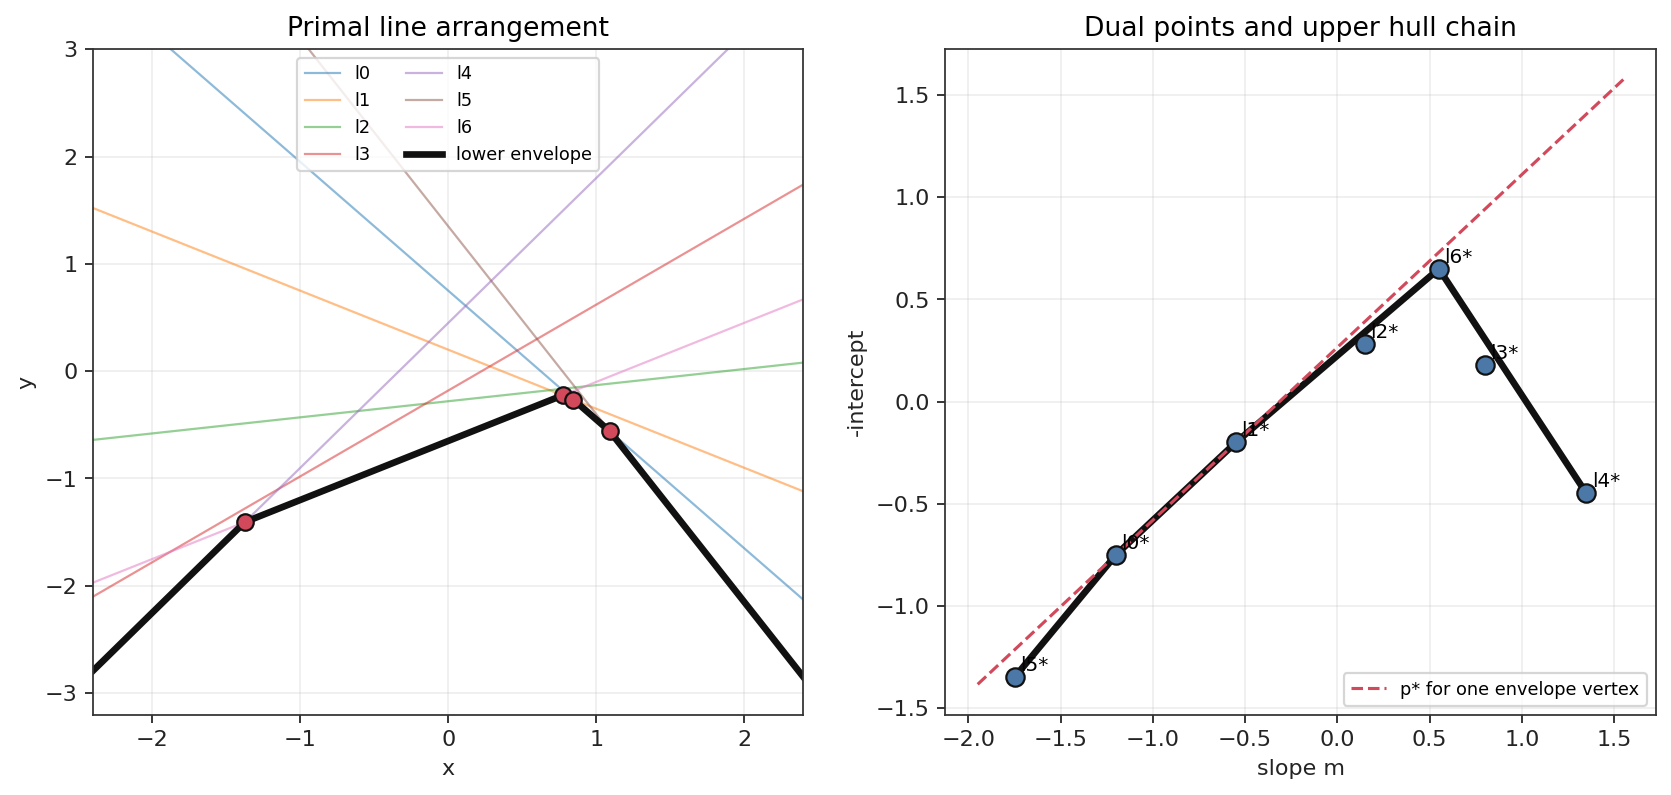

{'lower_envelope_vertex_pairs': [[0, 1], [0, 5], [1, 6], [4, 6]],
 'upper_hull_edge_pairs': [[0, 1], [0, 5], [1, 6], [4, 6]],
 'lower_vertices_match_upper_hull_edges': True,
 'incidence_residual_for_point_on_line': 0.0,
 'order_reversal_gap_for_point_below_line': 0.2,
 'order_reversal_verified': True}

In [8]:
line_rows = [
    {"label": "l0", "m": -1.20, "b": 0.75},
    {"label": "l1", "m": -0.55, "b": 0.20},
    {"label": "l2", "m": 0.15, "b": -0.28},
    {"label": "l3", "m": 0.80, "b": -0.18},
    {"label": "l4", "m": 1.35, "b": 0.45},
    {"label": "l5", "m": -1.75, "b": 1.35},
    {"label": "l6", "m": 0.55, "b": -0.65},
]
lines = pd.DataFrame(line_rows)
ms = lines["m"].to_numpy(float)
bs = lines["b"].to_numpy(float)
dual_points = np.column_stack([ms, -bs])

xline = np.linspace(-2.4, 2.4, 500)
yvals = ms[:, None] * xline[None, :] + bs[:, None]
lower_y = yvals.min(axis=0)

lower_vertices = []
for i, j in itertools.combinations(range(len(lines)), 2):
    if abs(ms[i] - ms[j]) < 1e-12:
        continue
    x0 = (bs[j] - bs[i]) / (ms[i] - ms[j])
    y0 = ms[i] * x0 + bs[i]
    if np.all(y0 <= ms * x0 + bs + 1e-9):
        lower_vertices.append({"pair": tuple(sorted((i, j))), "x": float(x0), "y": float(y0)})
lower_vertices = sorted(lower_vertices, key=lambda row: row["x"])

upper_hull_edges = []
for i, j in itertools.combinations(range(len(lines)), 2):
    x1, y1 = dual_points[i]
    x2, y2 = dual_points[j]
    if abs(x1 - x2) < 1e-12:
        continue
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    values_on_support = slope * dual_points[:, 0] + intercept
    if np.all(dual_points[:, 1] <= values_on_support + 1e-9):
        upper_hull_edges.append({"pair": tuple(sorted((i, j))), "slope": float(slope), "intercept": float(intercept)})
upper_hull_pairs = {edge["pair"] for edge in upper_hull_edges}
lower_vertex_pairs = {row["pair"] for row in lower_vertices}

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.4))
left, right = axes
for idx, row in lines.iterrows():
    y = row.m * xline + row.b
    left.plot(xline, y, lw=1.0, alpha=0.5, label=row.label)
left.plot(xline, lower_y, color="#111111", lw=3.0, label="lower envelope")
for vertex in lower_vertices:
    left.scatter([vertex["x"]], [vertex["y"]], s=55, color="#d1495b", edgecolors="#111111", zorder=4)
left.set_xlim(-2.4, 2.4)
left.set_ylim(-3.2, 3.0)
left.set_title("Primal line arrangement")
left.set_xlabel("x")
left.set_ylabel("y")
left.grid(True, alpha=0.2)
left.legend(ncol=2, fontsize=8, loc="upper center")

right.scatter(dual_points[:, 0], dual_points[:, 1], s=68, color="#4c78a8", edgecolors="#111111", zorder=4)
for i, (x, y) in enumerate(dual_points):
    right.text(x + 0.03, y + 0.03, f"l{i}*", fontsize=9)
for edge in upper_hull_edges:
    i, j = edge["pair"]
    right.plot([dual_points[i, 0], dual_points[j, 0]], [dual_points[i, 1], dual_points[j, 1]], color="#111111", lw=3.0)
chosen_vertex = lower_vertices[len(lower_vertices) // 2]
dual_x = np.linspace(dual_points[:, 0].min() - 0.2, dual_points[:, 0].max() + 0.2, 200)
dual_support_y = chosen_vertex["x"] * dual_x - chosen_vertex["y"]
right.plot(dual_x, dual_support_y, color="#d1495b", lw=1.4, linestyle="--", label="p* for one envelope vertex")
right.set_title("Dual points and upper hull chain")
right.set_xlabel("slope m")
right.set_ylabel("-intercept")
right.grid(True, alpha=0.2)
right.legend(loc="lower right", fontsize=8)

duality_board_path = save_matplotlib(fig, FIGURES / "point-line-duality-envelope-board.png")
plt.close(fig)

line_index = 3
m = ms[line_index]
b = bs[line_index]
a = 0.42
point_on_line = np.array([a, m * a + b])
dual_point_of_line = np.array([m, -b])
value_of_point_dual_at_m = point_on_line[0] * m - point_on_line[1]
incidence_residual = float(value_of_point_dual_at_m - dual_point_of_line[1])
point_below_line = np.array([a, m * a + b - 0.2])
value_of_below_point_dual_at_m = point_below_line[0] * m - point_below_line[1]
order_reversal_gap = float(value_of_below_point_dual_at_m - dual_point_of_line[1])

envelope_duality_check = {
    "lower_envelope_vertex_pairs": [list(pair) for pair in sorted(lower_vertex_pairs)],
    "upper_hull_edge_pairs": [list(pair) for pair in sorted(upper_hull_pairs)],
    "lower_vertices_match_upper_hull_edges": bool(lower_vertex_pairs == upper_hull_pairs),
    "incidence_residual_for_point_on_line": incidence_residual,
    "order_reversal_gap_for_point_below_line": order_reversal_gap,
    "order_reversal_verified": bool(order_reversal_gap > 0),
}
duality_envelope_check_path = save_json(envelope_duality_check, CHECKS / "point-line-duality-checks.json")
display_artifact(duality_board_path, width=900)
envelope_duality_check


## Applied Lab: Move One Site and Watch the Certificates Change

A Voronoi diagram is stable under small motion until a certificate changes: a nearest-site boundary moves, a Delaunay edge flips, or a cocircular event is crossed. The lab below moves one site horizontally and measures two visible effects: the fraction of raster query points whose nearest site changes and the number of Delaunay edges that differ from the baseline.


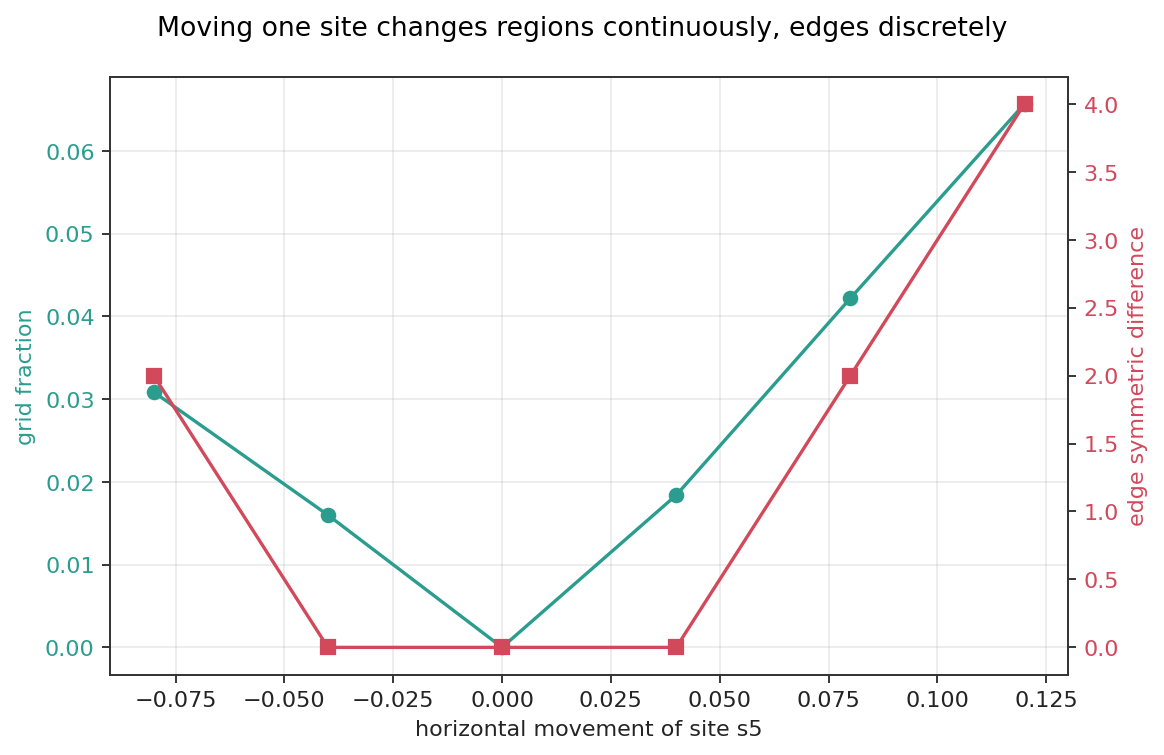

,moved_site,dx,changed_grid_fraction,delaunay_edge_symmetric_difference
0,5,-0.08,0.030855,2
1,5,-0.04,0.015995,0
2,5,0.00,0.000000,0
3,5,0.04,0.018394,0
4,5,0.08,0.042192,2
5,5,0.12,0.065690,4


In [9]:
def nearest_labels_for(points, queries):
    return np.argmin(((queries[:, None, :] - points[None, :, :]) ** 2).sum(axis=2), axis=1)

baseline_labels = nearest_labels_for(sites, queries)
baseline_edges = delaunay_edges(Delaunay(sites))
move_site = 5
lab_rows = []
for dx in [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]:
    moved = sites.copy()
    moved[move_site, 0] += dx
    labels = nearest_labels_for(moved, queries)
    moved_edges = delaunay_edges(Delaunay(moved))
    lab_rows.append({
        "moved_site": move_site,
        "dx": dx,
        "changed_grid_fraction": float(np.mean(labels != baseline_labels)),
        "delaunay_edge_symmetric_difference": int(len(baseline_edges ^ moved_edges)),
    })
lab = pd.DataFrame(lab_rows)
lab_csv_path = save_csv(lab_rows, TABLES / "site-motion-sensitivity.csv")

fig, ax1 = plt.subplots(figsize=(7.4, 4.8))
ax1.plot(lab["dx"], lab["changed_grid_fraction"], marker="o", color="#2a9d8f", label="changed nearest-site grid fraction")
ax1.set_xlabel("horizontal movement of site s5")
ax1.set_ylabel("grid fraction", color="#2a9d8f")
ax1.tick_params(axis="y", labelcolor="#2a9d8f")
ax1.grid(True, alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(lab["dx"], lab["delaunay_edge_symmetric_difference"], marker="s", color="#d1495b", label="Delaunay edge changes")
ax2.set_ylabel("edge symmetric difference", color="#d1495b")
ax2.tick_params(axis="y", labelcolor="#d1495b")
fig.suptitle("Moving one site changes regions continuously, edges discretely")
fig.tight_layout()
lab_plot_path = save_matplotlib(fig, FIGURES / "site-motion-sensitivity.png")
plt.close(fig)

lab_check = {
    "moved_site": move_site,
    "row_count": int(len(lab)),
    "zero_motion_changes_no_grid_labels": bool(lab.loc[lab["dx"] == 0.0, "changed_grid_fraction"].iloc[0] == 0.0),
    "zero_motion_changes_no_edges": bool(lab.loc[lab["dx"] == 0.0, "delaunay_edge_symmetric_difference"].iloc[0] == 0),
    "some_nonzero_motion_changes_grid": bool((lab.loc[lab["dx"] != 0.0, "changed_grid_fraction"] > 0).any()),
}
lab_check_path = save_json(lab_check, CHECKS / "site-motion-sensitivity.json")
display_artifact(lab_plot_path, width=720)
lab


## Final Sanity Checks

The final cell is deliberately redundant. It checks source coverage, artifact integrity, nearest-site classification, half-plane inequalities, Voronoi/Delaunay adjacency, the Euler-style ledger, incremental insertion, paraboloid lifting, and point-line duality.


In [10]:
source_coverage = {
    "source_pdf": "Discrete and Computational Geometry, 2nd Edition.pdf",
    "printed_pages": "107-135",
    "pdf_pages": "122-150",
    "sections_covered": [
        "4.1 Voronoi geometry: sites, nearest-site regions, bisectors, half-plane intersections, bounded/unbounded cells, empty circles",
        "4.2 Combinatorics and algorithms: Euler-style complexity bounds and incremental Voronoi insertion",
        "4.3 Revisiting the Delaunay triangulation: straight-line dual, empty-circle witness, incremental Delaunay update",
        "4.4 Revisiting the convex hull: lifting to z=x^2+y^2 and lower hull projection",
        "4.5 Geometric duality: point-line map, half-plane/envelope viewpoint, upper/lower envelopes, tangent planes",
    ],
    "required_storyboard_items": [
        "nearest-site colored grid",
        "bisector and half-plane cell construction",
        "Voronoi-Delaunay dual overlay",
        "combinatorics table for V/E/F",
        "incremental insertion snapshots",
        "paraboloid lifting lower hull 3D view",
        "point-line duality and envelope board",
    ],
}
source_coverage_path = save_json(source_coverage, CHECKS / "source-coverage.json")

artifact_paths = [
    routing_path,
    nearest_grid_path,
    nearest_check_path,
    halfplane_path,
    halfplane_check_path,
    dual_overlay_path,
    duality_check_path,
    complexity_csv_path,
    complexity_plot_path,
    complexity_check_path,
    incremental_path,
    incremental_check_path,
    lifting_html_path,
    lifting_check_path,
    duality_board_path,
    duality_envelope_check_path,
    lab_csv_path,
    lab_plot_path,
    lab_check_path,
    source_coverage_path,
]
assert_artifacts(artifact_paths, min_bytes=80)

assert nearest_check["matches_kdtree"]
assert nearest_check["bounded_iff_not_hull"]
assert halfplane_check["cell_area"] > 0
assert halfplane_check["max_halfspace_violation_at_vertices"] <= 1e-8
assert duality_check["edge_sets_agree"]
assert duality_check["empty_circle_is_empty"]
assert complexity_check["all_euler_ledgers_equal_2"]
assert complexity_check["all_vertex_bounds_hold"]
assert complexity_check["all_edge_bounds_hold"]
assert incremental_check["new_site_inside_old_hull"]
assert incremental_check["marked_triangle_count"] > 0
assert incremental_check["unmarked_old_triangles_survive"]
assert incremental_check["new_edges_match_cavity_boundary_vertices"]
assert lifting_check["lower_hull_projects_to_delaunay"]
assert envelope_duality_check["lower_vertices_match_upper_hull_edges"]
assert abs(envelope_duality_check["incidence_residual_for_point_on_line"]) < 1e-10
assert envelope_duality_check["order_reversal_verified"]
assert lab_check["zero_motion_changes_no_grid_labels"]
assert lab_check["zero_motion_changes_no_edges"]
assert lab_check["some_nonzero_motion_changes_grid"]

final_sanity = {
    "artifact_count_checked": len(artifact_paths),
    "all_core_checks_passed": True,
    "checked_artifacts": [str(path.relative_to(BOOK_ROOT)).replace("\\", "/") for path in artifact_paths],
    "source_sections_covered": source_coverage["sections_covered"],
}
final_sanity_path = save_json(final_sanity, CHECKS / "chapter-04-final-sanity.json")
assert_artifacts([final_sanity_path], min_bytes=80)
final_sanity


{'artifact_count_checked': 20,
 'all_core_checks_passed': True,
 'checked_artifacts': ['artifacts/chapter-04-voronoi-diagrams/tables/library-routing.csv',
  'artifacts/chapter-04-voronoi-diagrams/figures/nearest-site-grid.png',
  'artifacts/chapter-04-voronoi-diagrams/checks/nearest-site-grid-checks.json',
  'artifacts/chapter-04-voronoi-diagrams/figures/halfplane-cell-construction.png',
  'artifacts/chapter-04-voronoi-diagrams/checks/halfplane-cell-checks.json',
  'artifacts/chapter-04-voronoi-diagrams/figures/voronoi-delaunay-dual-overlay.png',
  'artifacts/chapter-04-voronoi-diagrams/checks/voronoi-delaunay-dual-checks.json',
  'artifacts/chapter-04-voronoi-diagrams/tables/voronoi-complexity-ledger.csv',
  'artifacts/chapter-04-voronoi-diagrams/figures/voronoi-complexity-bounds.png',
  'artifacts/chapter-04-voronoi-diagrams/checks/voronoi-complexity-ledger.json',
  'artifacts/chapter-04-voronoi-diagrams/figures/incremental-insertion-snapshots.png',
  'artifacts/chapter-04-voronoi-di

## Takeaways

- A Voronoi region is an intersection of ordinary Euclidean half-planes; convexity is a consequence of that translation.
- Hull sites own unbounded cells, while interior sites own bounded cells.
- The Delaunay triangulation is the straight-line dual of the Voronoi diagram when the point set is in general position, and empty circles are the local certificate.
- Voronoi diagrams have linear combinatorial complexity even though the set of all pairwise bisectors is quadratic.
- Incremental insertion is local in the diagram but can still have quadratic worst-case total work.
- Lifting to `z=x^2+y^2` makes Delaunay/Voronoi structure a shadow of a 3D convex hull and its tangent-plane dual.
- Point-line duality converts envelope and half-plane questions into convex-hull questions, preserving incidence while reversing vertical order.
